# EDA — Temperatura Superficial del Suelo (LST MODIS / GEE) · 2007–2024

Analisis exploratorio del dataset consolidado de temperatura superficial por municipio, extraido de Google Earth Engine usando MODIS Land Surface Temperature.

**Prerrequisito:** haber corrido `07_Combinar_GEE_LST.ipynb`.

**Variables clave:**
- `lst_celsius`: temperatura superficial diaria en grados Celsius (`mean_raw × 0.02 − 273.15`)
- `ADM2_CODE`: codigo de municipio (equivalente a `COD_MUN_O` en SIVIGILA)
- Nulos (~60%): ausencia de datos por nubosidad — normal en MODIS LST

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (12, 4),
                     'axes.spines.top': False, 'axes.spines.right': False})

In [2]:
CSV = r"C:\Users\nilara\Downloads\dengue_project\data\processed\gee_lst_municipios.csv"

## 1. Carga y vista general

In [3]:
df = pd.read_csv(CSV, parse_dates=['fecha'], low_memory=False)
df['mes'] = df['fecha'].dt.month
print(f"Filas: {len(df):,}  |  Columnas: {df.shape[1]}")
print(f"Rango: {df['fecha'].min().date()} → {df['fecha'].max().date()}")
print(f"Municipios: {df['ADM2_CODE'].nunique():,}  |  Departamentos: {df['ADM1_NAME'].nunique()}")
print(f"Nulos LST: {df['lst_celsius'].isna().mean()*100:.1f}%")
df.head(3)

Filas: 7,140,450  |  Columnas: 8
Rango: 2007-01-01 → 2024-12-31


Municipios: 1,086  |  Departamentos: 33
Nulos LST: 59.7%


,source_file,ADM1_CODE,ADM1_NAME,ADM2_CODE,ADM2_NAME,fecha,lst_celsius,mes
0,2007,935,Antioquia,13341,Abejorral,2007-01-01,24.051682,1
1,2007,935,Antioquia,13342,Abriaqui,2007-01-01,21.561569,1
2,2007,935,Antioquia,13343,Alejandria,2007-01-01,19.093211,1


## 2. Datos faltantes por año (nubosidad)

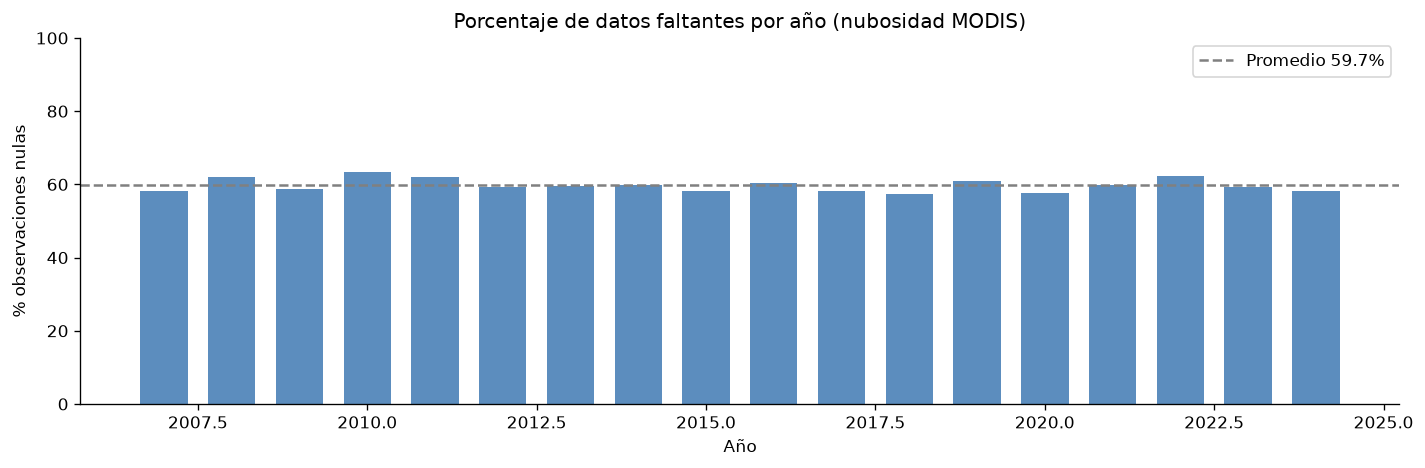

,Año,Nulos (%)
0,2007,58.2%
1,2008,62.0%
2,2009,58.6%
3,2010,63.4%
4,2011,61.9%
5,2012,59.4%
6,2013,59.6%
7,2014,59.7%
8,2015,58.3%
9,2016,60.5%


In [4]:
nulos_ano = df.groupby('source_file')['lst_celsius'].apply(lambda x: x.isna().mean()*100)

fig, ax = plt.subplots()
ax.bar(nulos_ano.index, nulos_ano.values, color='#5C8DBE', width=0.7)
ax.axhline(nulos_ano.mean(), linestyle='--', color='gray',
           label=f'Promedio {nulos_ano.mean():.1f}%')
ax.set_ylim(0, 100)
ax.set_xlabel('Año')
ax.set_ylabel('% observaciones nulas')
ax.set_title('Porcentaje de datos faltantes por año (nubosidad MODIS)')
ax.legend()
plt.tight_layout()
plt.show()

display(nulos_ano.reset_index().rename(columns={'source_file':'Año','lst_celsius':'Nulos (%)'})
        .style.format({'Nulos (%)': '{:.1f}%'}))

## 3. Distribucion de temperatura (valores validos)

            LST (C)
count  2.874442e+06
mean   2.517453e+01
std    5.624191e+00
min   -3.733000e+01
25%    2.175890e+01
50%    2.547663e+01
75%    2.875441e+01
max    5.161725e+01


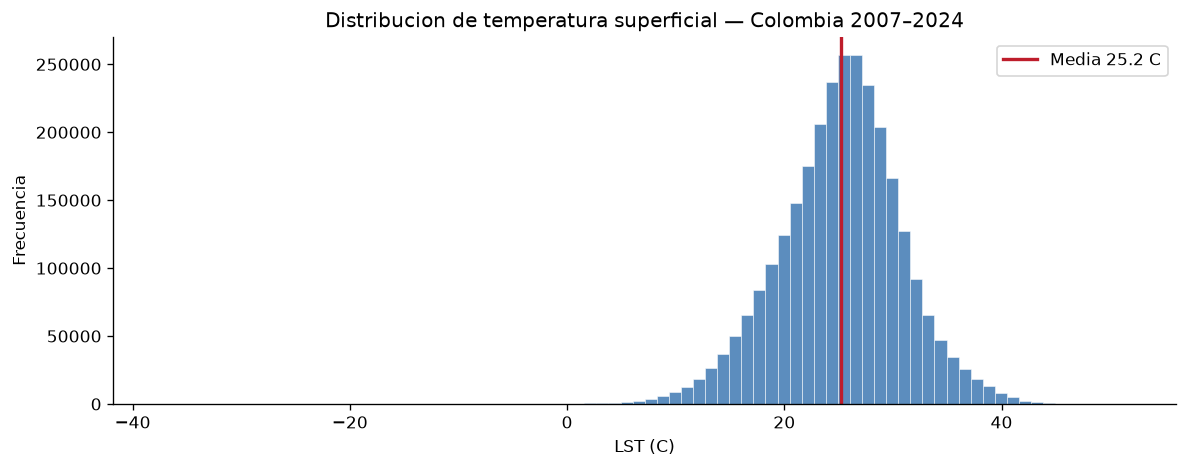


Valores < -10 C: 45  (posibles artefactos MODIS en nieves)
Valores > 50 C:  3  (zonas deserticas/superficies muy calientes)


In [5]:
df_v = df.dropna(subset=['lst_celsius'])
print(df_v['lst_celsius'].describe().rename('LST (C)').to_frame())

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df_v['lst_celsius'], bins=80, color='#5C8DBE', edgecolor='white', linewidth=0.3)
ax.axvline(df_v['lst_celsius'].mean(), color='#BE1D2B', linewidth=2,
           label=f"Media {df_v['lst_celsius'].mean():.1f} C")
ax.set_xlabel('LST (C)')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribucion de temperatura superficial — Colombia 2007–2024')
ax.legend()
plt.tight_layout()
plt.show()

# Posibles outliers extremos
print(f"\nValores < -10 C: {(df_v['lst_celsius'] < -10).sum():,}  (posibles artefactos MODIS en nieves)")
print(f"Valores > 50 C:  {(df_v['lst_celsius'] > 50).sum():,}  (zonas deserticas/superficies muy calientes)")

## 4. Temperatura media mensual (estacionalidad)

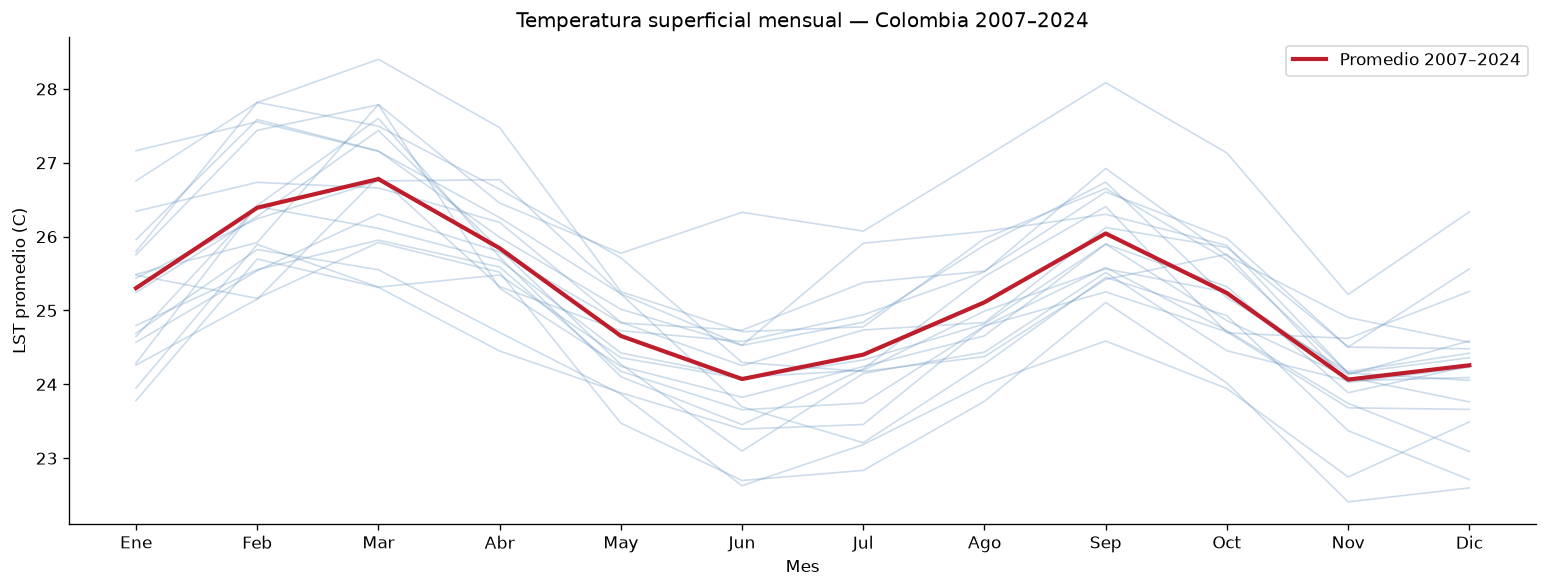

In [6]:
temp_mes_ano = df_v.groupby(['source_file','mes'])['lst_celsius'].mean().reset_index()
temp_mes_global = df_v.groupby('mes')['lst_celsius'].mean()

fig, ax = plt.subplots(figsize=(13, 5))
for year in sorted(df['source_file'].unique()):
    sub = temp_mes_ano[temp_mes_ano['source_file'] == year]
    ax.plot(sub['mes'], sub['lst_celsius'], alpha=0.3, color='#5C8DBE', linewidth=1)
ax.plot(temp_mes_global.index, temp_mes_global.values,
        color='#BE1D2B', linewidth=2.5, label='Promedio 2007–2024')
ax.set_xticks(range(1,13))
ax.set_xticklabels(['Ene','Feb','Mar','Abr','May','Jun',
                    'Jul','Ago','Sep','Oct','Nov','Dic'])
ax.set_xlabel('Mes')
ax.set_ylabel('LST promedio (C)')
ax.set_title('Temperatura superficial mensual — Colombia 2007–2024')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Temperatura promedio anual

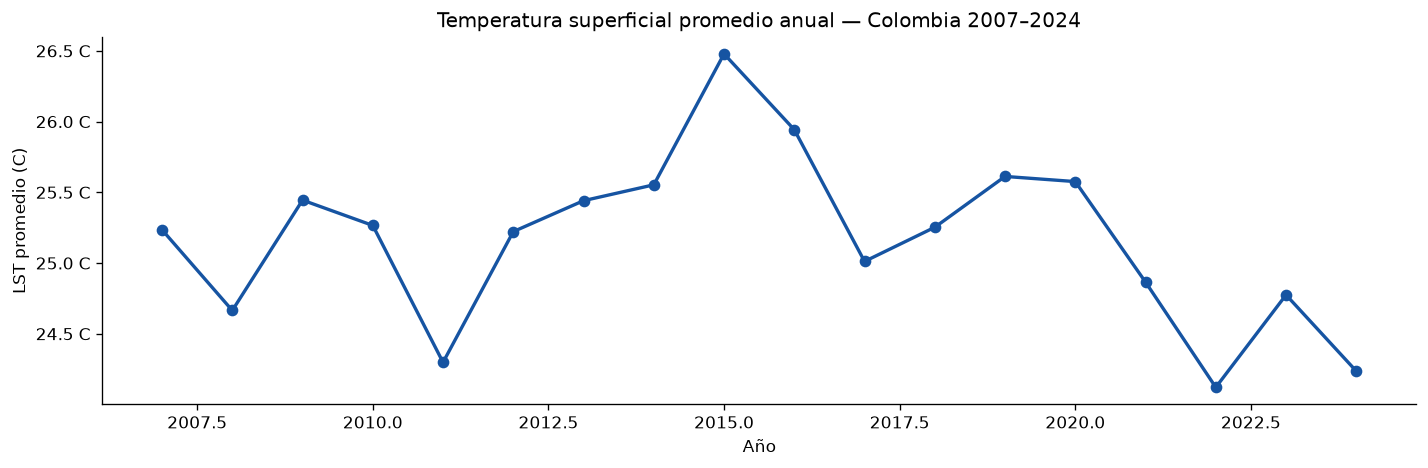

,Año,LST media (C)
0,2007,25.24
1,2008,24.66
2,2009,25.44
3,2010,25.27
4,2011,24.30
5,2012,25.22
6,2013,25.44
7,2014,25.55
8,2015,26.48
9,2016,25.94


In [7]:
temp_ano = df_v.groupby('source_file')['lst_celsius'].mean()

fig, ax = plt.subplots()
ax.plot(temp_ano.index, temp_ano.values, marker='o', color='#1654A2', linewidth=2)
ax.set_xlabel('Año')
ax.set_ylabel('LST promedio (C)')
ax.set_title('Temperatura superficial promedio anual — Colombia 2007–2024')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f C'))
plt.tight_layout()
plt.show()

display(temp_ano.reset_index().rename(columns={'source_file':'Año','lst_celsius':'LST media (C)'})
        .style.format({'LST media (C)': '{:.2f}'}))

## 6. Distribucion geografica — por departamento

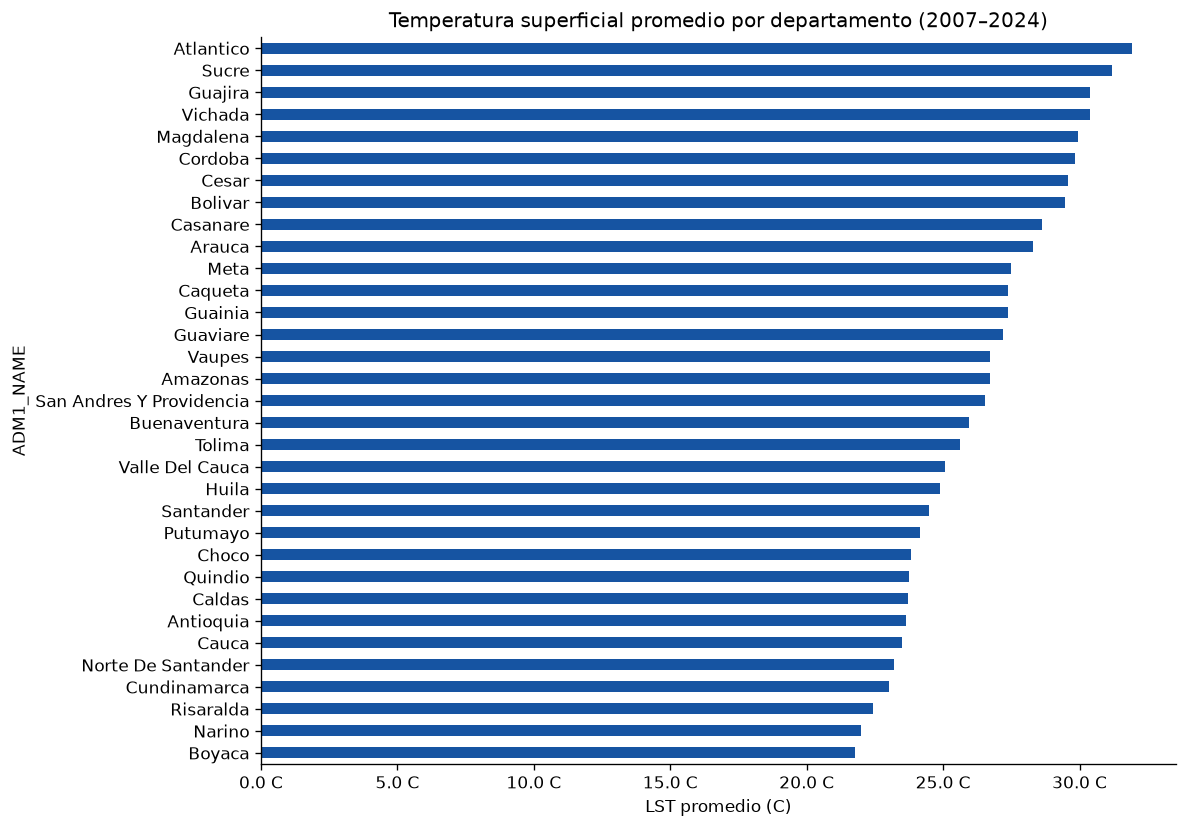

,Media (C),Std (C),Observaciones
ADM1_NAME,,,
Atlantico,31.94,4.28,"74,162"
Sucre,31.18,4.50,"60,516"
Guajira,30.37,4.92,"45,645"
Vichada,30.37,4.06,"25,001"
Magdalena,29.95,5.24,"76,539"
Cordoba,29.84,3.87,"63,690"
Cesar,29.59,4.74,"83,176"
Bolivar,29.48,3.92,"130,715"
Casanare,28.63,5.22,"52,770"


In [8]:
temp_dpto = (df_v.groupby('ADM1_NAME')['lst_celsius']
             .agg(['mean','std','count'])
             .sort_values('mean', ascending=False))
temp_dpto.columns = ['Media (C)', 'Std (C)', 'Observaciones']

fig, ax = plt.subplots(figsize=(10, 7))
temp_dpto['Media (C)'].sort_values().plot.barh(ax=ax, color='#1654A2')
ax.set_xlabel('LST promedio (C)')
ax.set_title('Temperatura superficial promedio por departamento (2007–2024)')
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f C'))
plt.tight_layout()
plt.show()

display(temp_dpto.style.format({'Media (C)': '{:.2f}', 'Std (C)': '{:.2f}',
                                'Observaciones': '{:,}'}))

## 7. Cobertura por municipio — % de dias con dato

Cobertura media por municipio: 40.3%
Municipios con < 20% de datos: 19
Municipios con > 50% de datos: 183


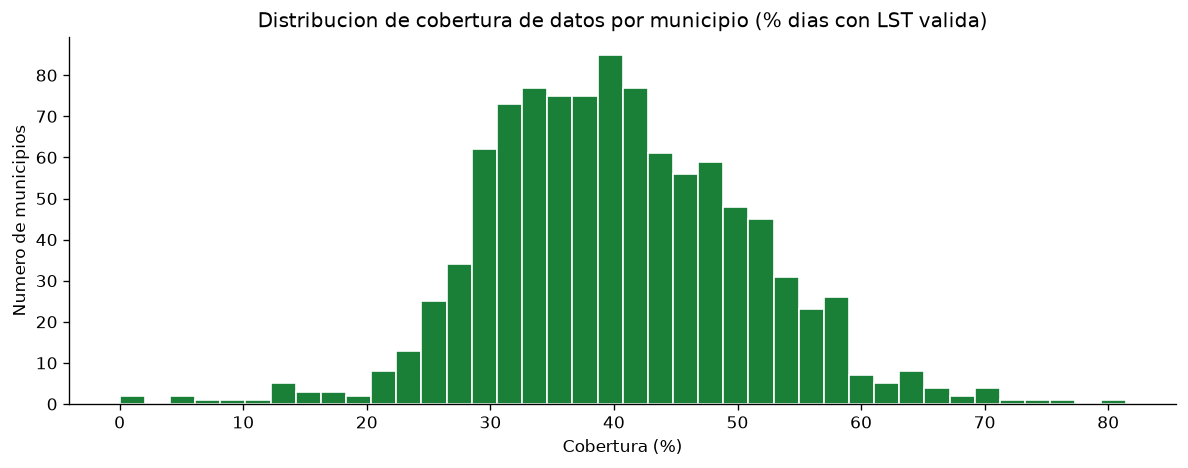

In [9]:
cobertura = (df.groupby('ADM2_NAME')['lst_celsius']
             .apply(lambda x: x.notna().mean() * 100)
             .rename('cobertura_%'))

print(f"Cobertura media por municipio: {cobertura.mean():.1f}%")
print(f"Municipios con < 20% de datos: {(cobertura < 20).sum()}")
print(f"Municipios con > 50% de datos: {(cobertura > 50).sum()}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(cobertura.values, bins=40, color='#1A7F37', edgecolor='white')
ax.set_xlabel('Cobertura (%)')
ax.set_ylabel('Numero de municipios')
ax.set_title('Distribucion de cobertura de datos por municipio (% dias con LST valida)')
plt.tight_layout()
plt.show()